## Загрузка данных

In [ ]:
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

In [5]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

file_path = "../data/interim/top_podcasts_debug.csv"
df = pd.read_csv(file_path)
display(Markdown(f"### Прочитано: `{df.shape[0]:,}` строк, `{df.shape[1]}` колонок"))

### Прочитано: `199,999` строк, `16` колонок

In [6]:
overview = pd.DataFrame({
    "Тип данных": df.dtypes,
    "Число уникальных значений": df.nunique(),
    "Доля пропусков": df.isna().mean() * 100
})

overview

,Тип данных,Число уникальных значений,Доля пропусков
date,str,46,0.000000
rank,int64,200,0.000000
region,str,22,0.000000
chartRankMove,str,4,0.000000
episodeUri,str,41502,0.000000
showUri,str,4444,0.000000
episodeName,str,41073,0.000000
description,str,38122,1.152006
show.name,str,4489,0.000000
show.publisher,str,3505,0.000000


### Сериализация

In [7]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)


parquet_path = processed_dir / "top_podcasts.parquet"
feather_path = processed_dir / "top_podcasts.feather"
pickle_path = processed_dir / "top_podcasts.pkl"
csv_path = Path(file_path)

df.to_parquet(parquet_path, index=False)
df.to_feather(feather_path)
df.to_pickle(pickle_path)

#### Размер файлов

In [8]:
def get_file_size_mb(path): #если что отредачь
    return path.stat().st_size / (1024 ** 2)


print("Parquet:", round(get_file_size_mb(parquet_path),4), "MB")
print("Feather:", round(get_file_size_mb(feather_path),4), "MB")
print("Pickle:", round(get_file_size_mb(pickle_path),4), "MB")
print("CSV:", round(get_file_size_mb(csv_path),4),"МВ")

Parquet: 104.1239 MB
Feather: 125.4882 MB
Pickle: 212.1217 MB
CSV: 196.7359 МВ


#### Время записи


In [9]:
def measure_write_time(write_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        write_function()

        end = time.perf_counter()
        times.append(end - start)

    return statistics.median(times)


parquet_write_time = measure_write_time(
    lambda: df.to_parquet(parquet_path, index=False)
)

feather_write_time = measure_write_time(
    lambda: df.to_feather(feather_path)
)

pickle_write_time = measure_write_time(
    lambda: df.to_pickle(pickle_path)
)

#### Время чтения

In [10]:
def measure_read_time(read_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        read_function()

        end = time.perf_counter()
        times.append(end - start)

    return statistics.median(times)


parquet_read_time = measure_read_time(
    lambda: pd.read_parquet(parquet_path)
)

feather_read_time = measure_read_time(
    lambda: pd.read_feather(feather_path)
)

pickle_read_time = measure_read_time(
    lambda: pd.read_pickle(pickle_path)
)
csv_read_time = measure_read_time(
    lambda: pd.read_csv(csv_path)
)

In [11]:
selected_columns = ["date", "rank", "region"]

parquet_three_columns_read_time = measure_read_time(
    lambda: pd.read_parquet(
        parquet_path,
        columns=selected_columns
    )
)

In [12]:
results = pd.DataFrame([
    {
        "format": "Parquet",
        "file_size_mb": get_file_size_mb(parquet_path),
        "write_time_median": parquet_write_time,
        "read_time_median": parquet_read_time
    },
    {
        "format": "Feather",
        "file_size_mb": get_file_size_mb(feather_path),
        "write_time_median": feather_write_time,
        "read_time_median": feather_read_time
    },
    {
        "format": "Pickle",
        "file_size_mb": get_file_size_mb(pickle_path),
        "write_time_median": pickle_write_time,
        "read_time_median": pickle_read_time
    },
    {
        "format": "CSV",
        "file_size_mb": get_file_size_mb(csv_path),
        "write_time_median": None,
        "read_time_median": csv_read_time
    },
])

results

,format,file_size_mb,write_time_median,read_time_median
0,Parquet,104.123889,10.430845,0.632326
1,Feather,125.488207,17.219059,0.185862
2,Pickle,212.121748,18.053508,0.205438
3,CSV,196.735893,NaN,4.110369


In [13]:
parquet_columns_results = pd.DataFrame([
    {
        "read_type": "Весь файл",
        "time_median": parquet_read_time
    },
    {
        "read_type": "3 столбца",
        "time_median": parquet_three_columns_read_time
    }
])

parquet_columns_results

,read_type,time_median
0,Весь файл,0.632326
1,3 столбца,0.017580


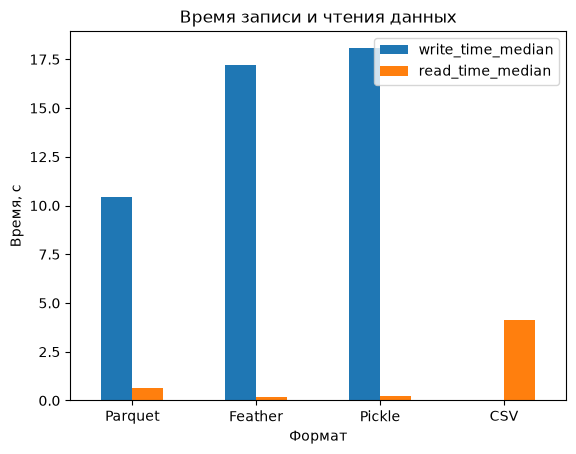

In [14]:

results.plot(
    x="format",
    y=["write_time_median", "read_time_median"],
    kind="bar"
)

plt.ylabel("Время, с")
plt.xlabel("Формат")
plt.title("Время записи и чтения данных")
plt.xticks(rotation=0)
plt.show()

В ходе эксперимента были сравнены форматы Parquet, Feather и Pickle по размеру файла, времени записи и времени чтения. Для каждого показателя использовались три измерения, а в качестве итогового значения использовалась медиана.

Формат Parquet занял 104 МБ, время записи составило 10.427056 с, а время чтения — 0.717117с. Формат Parquet показал лучший результат по размеру/скорости.

Дополнительно было проведено сравнение чтения всего файла Parquet и только трёх столбцов. Чтение трёх столбцов заняло 0.026082 с против 0.717117 с для полного файла.

Для дальнейшей работы выбран формат Parquet, поскольку для данного проекта наиболее важна быстрая обработка данных.

### Оптимизация схемы данных

In [21]:
import statistics
import time
from pathlib import Path
import sys

sys.path.append("..")

import pandas as pd
from IPython.display import Markdown, display

from src.config import DATA_SCHEMA, DEBUG_DATA_PATH, PROCESSED_DIR

start = time.perf_counter()

df_before = pd.read_csv(DEBUG_DATA_PATH)

read_time_before = time.perf_counter() - start

display(Markdown(  f"#### Прочитано: `{df_before.shape[0]:,}` строк, " f"`{df_before.shape[1]}` колонок" ))

display(Markdown(f"#### Время чтения: `{read_time_before:.4f}` сек"))



#### Прочитано: `199,999` строк, `16` колонок

#### Время чтения: `4.3721` сек

In [ ]:
memory_before = (df_before.memory_usage(deep=True).rename("Память, байт").to_frame())

memory_before["Память, МБ"] = ( memory_before["Память, байт"] / (1024 ** 2))

memory_before

,"Память, байт","Память, МБ"
Index,132,0.000126
date,3599982,3.433210
rank,1599992,1.525871
region,1999990,1.907339
chartRankMove,2284162,2.178347
episodeUri,5999970,5.722017
showUri,5999970,5.722017
episodeName,12097467,11.537044
description,165442088,157.777870
show.name,5964383,5.688079


In [23]:
text_columns = df_before.select_dtypes(
    include=["object", "string"]
).columns

text_unique_share = pd.DataFrame({
    "Столбец": text_columns,
    "Уникальных значений": [
        df_before[column].nunique(dropna=False)
        for column in text_columns
    ],
    "Доля уникальных": [
        df_before[column].nunique(dropna=False) / len(df_before)
        for column in text_columns
    ]
})

text_unique_share["Доля уникальных, %"] = (
    text_unique_share["Доля уникальных"] * 100
)

text_unique_share = text_unique_share.drop(
    columns="Доля уникальных"
)

text_unique_share

,Столбец,Уникальных значений,"Доля уникальных, %"
0,date,46,0.023000
1,region,22,0.011000
2,chartRankMove,4,0.002000
3,episodeUri,41502,20.751104
4,showUri,4444,2.222011
5,episodeName,41073,20.536603
6,description,38123,19.061595
7,show.name,4489,2.244511
8,show.publisher,3505,1.752509
9,languages,58,0.029000


In [25]:
def apply_schema(df, schema):
    df = df.copy()

    for column, dtype in schema.items():

        if dtype == "datetime":
            df[column] = pd.to_datetime(
                df[column],
                errors="coerce"
            )

        elif dtype == "category":
            df[column] = df[column].astype("category")

        elif dtype == "string":
            df[column] = df[column].astype("string")

        elif dtype == "int32":
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            ).astype("Int32")

        elif dtype == "boolean":
            df[column] = df[column].astype("boolean")

    return df

In [27]:
df_after = apply_schema(
    df_before,
    DATA_SCHEMA
)

df_after.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 199999 entries, 0 to 199998
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 199999 non-null  datetime64[us]
 1   rank                 199999 non-null  Int32         
 2   region               199999 non-null  category      
 3   chartRankMove        199999 non-null  category      
 4   episodeUri           199999 non-null  string        
 5   showUri              199999 non-null  string        
 6   episodeName          199999 non-null  string        
 7   description          197695 non-null  string        
 8   show.name            199999 non-null  string        
 9   show.publisher       199999 non-null  string        
 10  duration_ms          199999 non-null  Int32         
 11  explicit             199999 non-null  boolean       
 12  languages            199999 non-null  category      
 13  release_date         1999

In [28]:
df_after.dtypes

date                   datetime64[us]
rank                            Int32
region                       category
chartRankMove                category
episodeUri                     string
showUri                        string
episodeName                    string
description                    string
show.name                      string
show.publisher                 string
duration_ms                     Int32
explicit                      boolean
languages                    category
release_date                      str
show.media_type                   str
show.total_episodes           float64
dtype: object

In [29]:
category_columns = df_after.select_dtypes(include="category").columns

print("Столбцы category:")
print(list(category_columns))

print(f"\nКоличество столбцов category: " f"{len(category_columns)}")

Столбцы category:
['region', 'chartRankMove', 'languages']

Количество столбцов category: 3


In [ ]:
memory_after = ( df_after.memory_usage(deep=True).rename("Память, байт").to_frame())

memory_after["Память, МБ"] = (memory_after["Память, байт"] / (1024 ** 2))

memory_after

,"Память, байт","Память, МБ"
Index,132,0.000126
date,1599992,1.525871
rank,999995,0.953670
region,200222,0.190947
chartRankMove,200050,0.190783
episodeUri,5999970,5.722017
showUri,5999970,5.722017
episodeName,12097467,11.537044
description,165442088,157.777870
show.name,5964383,5.688079


In [31]:
memory_comparison = pd.DataFrame({ "До, МБ": memory_before["Память, МБ"],"После, МБ": memory_after["Память, МБ"]
})

memory_comparison["Изменение, МБ"] = ( memory_comparison["После, МБ"] - memory_comparison["До, МБ"])

memory_comparison

,"До, МБ","После, МБ","Изменение, МБ"
Index,0.000126,0.000126,0.000000
date,3.433210,1.525871,-1.907339
rank,1.525871,0.953670,-0.572202
region,1.907339,0.190947,-1.716393
chartRankMove,2.178347,0.190783,-1.987564
episodeUri,5.722017,5.722017,0.000000
showUri,5.722017,5.722017,0.000000
episodeName,11.537044,11.537044,0.000000
description,157.777870,157.777870,0.000000
show.name,5.688079,5.688079,0.000000


In [32]:
optimized_path = PROCESSED_DIR / "top_podcasts_optimized.parquet"

df_after.to_parquet(optimized_path,index=False,compression="snappy")

def get_file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)


optimized_size_mb = get_file_size_mb(optimized_path)

print(f"Размер оптимизированного файла: "f"{optimized_size_mb:.2f} МБ")


before_path = PROCESSED_DIR / "top_podcasts_before.parquet"

df_before.to_parquet(before_path,index=False,compression="snappy")

before_size_mb = get_file_size_mb(before_path)

print(f"Размер файла до оптимизации: "f"{before_size_mb:.2f} МБ")

Размер оптимизированного файла: 104.07 МБ
Размер файла до оптимизации: 104.12 МБ


In [33]:
def measure_read_time(read_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        read_function()

        end = time.perf_counter()

        times.append(end - start)

    return statistics.median(times)


read_before = measure_read_time(lambda: pd.read_parquet(before_path))

read_after = measure_read_time(lambda: pd.read_parquet(optimized_path))

print(f"До оптимизации: {read_before:.4f} с")
print(f"После оптимизации: {read_after:.4f} с")

До оптимизации: 1.6111 с
После оптимизации: 0.6462 с


In [34]:
def measure_groupby_time(df, column, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        df.groupby(column,observed=True).size()

        end = time.perf_counter()

        times.append(end - start)

    return statistics.median(times)

groupby_before = measure_groupby_time(df_before,"region")

groupby_after = measure_groupby_time(df_after,"region")

print(f"Группировка до оптимизации: {groupby_before:.6f} с")
print(f"Группировка после оптимизации: {groupby_after:.6f} с")

Группировка до оптимизации: 0.009536 с
Группировка после оптимизации: 0.006704 с


In [ ]:
memory_before_total = df_before.memory_usage(deep=True).sum() / (1024 ** 2)

memory_after_total = df_after.memory_usage(deep=True).sum() / (1024 ** 2)

category_count = len(category_columns)

results = pd.DataFrame([
    {
        "Показатель": "Объём файла на диске, МБ",
        "До оптимизации": before_size_mb,
        "После": optimized_size_mb,
        "Изменение": optimized_size_mb - before_size_mb
    },
    {
        "Показатель": "Объём в памяти, МБ",
        "До оптимизации": memory_before_total,
        "После": memory_after_total,
        "Изменение": memory_after_total - memory_before_total
    },
    {
        "Показатель": "Время чтения, с",
        "До оптимизации": read_before,
        "После": read_after,
        "Изменение": read_after - read_before
    },
    {
        "Показатель": "Время группировки, с",
        "До оптимизации": groupby_before,
        "После": groupby_after,
        "Изменение": groupby_after - groupby_before
    },
    {
        "Показатель": "Число столбцов типа category",
        "До оптимизации": 0,
        "После": category_count,
        "Изменение": category_count
    }
])

results.round(4)

,Показатель,До оптимизации,После,Изменение
0,"Объём файла на диске, МБ",104.1239,104.0666,-0.0573
1,"Объём в памяти, МБ",212.1188,202.9660,-9.1528
2,"Время чтения, с",1.6111,0.6462,-0.9649
3,"Время группировки, с",0.0095,0.0067,-0.0028
4,Число столбцов типа category,0.0000,3.0000,3.0000
